In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer

In [2]:
dataset = pd.read_csv(r"C:\Users\Disha\TU Braunschweig\Thesis\Data_2025\Merged Dataset.csv")

In [3]:
dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR)
0,Austria,2020,6.41,"380,317.90",1.381911,-1.6,26797.0,39.325301,403.164557,97.0,57.761446,286.20,38311.38
1,Austria,2021,13.92,"406,231.50",2.766667,2.0,39904.0,40.904348,493.391304,168.0,64.046957,308.73,40745.01
2,Austria,2022,15.70,"449,382.20",8.546870,2.7,61393.0,49.314815,594.259259,253.0,73.787037,345.44,43874.27
3,Austria,2023,19.91,"477,837.30",7.814134,0.8,76773.0,70.307692,649.230769,371.0,79.230769,NaN,45999.05
4,Austria,2024,17.58,"494,087.60",2.937916,0.1,102562.0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
dataset.shape

(162, 13)

In [5]:
# Check structure
dataset.info()

# Basic stats
dataset.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 13 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Country                                         162 non-null    object 
 1   Year                                            162 non-null    int64  
 2   BEV Percentage (Total Number Of Registrations)  162 non-null    float64
 3   GDP                                             136 non-null    object 
 4   CPI                                             158 non-null    float64
 5   EG                                              135 non-null    float64
 6   Recharging Points                               135 non-null    float64
 7   AC Recharging Speed (km/h)                      108 non-null    float64
 8   DC Recharging Speed (km/h)                      108 non-null    float64
 9   Available                                  

,count,mean,std,min,25%,50%,75%,max
Year,162.0,2022.500000,1.713121,2020.000000,2021.000000,2022.500000,2024.000000,2025.000000
BEV Percentage (Total Number Of Registrations),162.0,11.072901,11.354090,0.420000,3.172500,6.400000,16.502500,68.530000
CPI,158.0,4.500832,4.143497,-1.247984,1.899522,3.210436,6.226421,19.705046
EG,135.0,1.211852,2.043886,-4.400000,0.100000,1.100000,2.300000,6.900000
Recharging Points,135.0,62912.614815,126438.893300,0.000000,3138.500000,10475.000000,52652.500000,675302.000000
AC Recharging Speed (km/h),108.0,49.963039,12.402048,39.325301,40.509586,45.109581,54.563034,70.307692
DC Recharging Speed (km/h),108.0,535.011472,94.875683,403.164557,470.834618,543.825282,608.002137,649.230769
Available,108.0,222.250000,102.582278,97.000000,150.250000,210.500000,282.500000,371.000000
Battery Capacity,108.0,68.706552,8.376702,57.761446,62.475579,68.916997,75.147970,79.230769
Real Range,81.0,313.456667,24.566599,286.200000,286.200000,308.730000,345.440000,345.440000


# 1. Preprocessing

## A. Convert to similar dataype

In [6]:
# Convert GDP to float
dataset["GDP"] = (
    dataset["GDP"]
    .astype(str)
    .str.replace(",", "")     
    .astype(float)
)

# Verify datatypes 
print(dataset.dtypes)

Country                                            object
Year                                                int64
BEV Percentage (Total Number Of Registrations)    float64
GDP                                               float64
CPI                                               float64
EG                                                float64
Recharging Points                                 float64
AC Recharging Speed (km/h)                        float64
DC Recharging Speed (km/h)                        float64
Available                                         float64
Battery Capacity                                  float64
Real Range                                        float64
Purchase price (EUR)                              float64
dtype: object


## B. Treating null values.

In [7]:
# Finding null values in the dataset
dataset.isnull().sum()

Country                                            0
Year                                               0
BEV Percentage (Total Number Of Registrations)     0
GDP                                               26
CPI                                                4
EG                                                27
Recharging Points                                 27
AC Recharging Speed (km/h)                        54
DC Recharging Speed (km/h)                        54
Available                                         54
Battery Capacity                                  54
Real Range                                        81
Purchase price (EUR)                              54
dtype: int64

**i. Gross Domestic Profit**

In [8]:
gdp = dataset[dataset['GDP'].isnull()][['Country', 'Year', 'GDP']]
print(gdp)

            Country  Year  GDP
5           Austria  2025  NaN
11          Belgium  2025  NaN
17         Bulgaria  2025  NaN
23          Croatia  2025  NaN
29           Cyprus  2025  NaN
35   Czech Republic  2025  NaN
41          Denmark  2025  NaN
47          Estonia  2025  NaN
53          Finland  2025  NaN
59           France  2025  NaN
71           Greece  2025  NaN
77          Hungary  2025  NaN
83          Ireland  2025  NaN
89            Italy  2025  NaN
95           Latvia  2025  NaN
101       Lithuania  2025  NaN
107      Luxembourg  2025  NaN
113           Malta  2025  NaN
119     Netherlands  2025  NaN
125          Poland  2025  NaN
131        Portugal  2025  NaN
137         Romania  2025  NaN
143        Slovakia  2025  NaN
149        Slovenia  2025  NaN
155           Spain  2025  NaN
161          Sweden  2025  NaN


In [9]:
# Verification
print(dataset.loc[dataset['Country'] == 'Ireland', ['Country', 'Year', 'GDP']])

    Country  Year       GDP
78  Ireland  2020  381728.7
79  Ireland  2021  448445.1
80  Ireland  2022  520718.4
81  Ireland  2023  524728.8
82  Ireland  2024  562794.2
83  Ireland  2025       NaN


In [10]:
# Replace 0 with NaN to handle missing data
dataset["GDP"].replace(0, np.nan, inplace=True)

# Fill 2025 only for countries where it's missing
for country in dataset.loc[dataset["Year"] == 2025, "Country"].unique():
    if dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "GDP"].isna().any():
        country_data = dataset[dataset["Country"] == country]
        
        # Get 2023 and 2024 GDP
        val_2023 = country_data.loc[country_data["Year"] == 2023, "GDP"].values
        val_2024 = country_data.loc[country_data["Year"] == 2024, "GDP"].values
        
        # Only fill if both 2023 and 2024 exist
        if len(val_2023) > 0 and len(val_2024) > 0:
            growth = val_2024[0] / val_2023[0] if val_2023[0] != 0 else 1.0
            # Fill 2025
            dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "GDP"] = val_2024[0] * growth

# Verify 
pd.set_option('display.float_format', '{:.1f}'.format)
print(dataset.loc[dataset["Year"] == 2025, ["Country", "Year", "GDP"]])

            Country  Year        GDP
5           Austria  2025   510890.5
11          Belgium  2025   638698.9
17         Bulgaria  2025   227109.3
23          Croatia  2025    93194.2
29           Cyprus  2025    37268.7
35   Czech Republic  2025  8475024.6
41          Denmark  2025  3072750.7
47          Estonia  2025    41400.2
53          Finland  2025   279113.6
59           France  2025  3016341.9
65          Germany  2025  4470480.0
71           Greece  2025   249432.0
77          Hungary  2025 88105816.2
83          Ireland  2025   603621.0
89            Italy  2025  2258154.4
95           Latvia  2025    41170.6
101       Lithuania  2025    83970.0
107      Luxembourg  2025    90446.3
113           Malta  2025    25453.9
119     Netherlands  2025  1199766.3
125          Poland  2025  3908197.5
131        Portugal  2025   309849.3
137         Romania  2025  1945451.5
143        Slovakia  2025   137236.3
149        Slovenia  2025    70963.3
155           Spain  2025  1697125.3
1

In [11]:
# Verification
print(dataset.loc[dataset['Country'] == 'Ireland', ['Country', 'Year', 'GDP']])

    Country  Year      GDP
78  Ireland  2020 381728.7
79  Ireland  2021 448445.1
80  Ireland  2022 520718.4
81  Ireland  2023 524728.8
82  Ireland  2024 562794.2
83  Ireland  2025 603621.0


**ii. Consumer Price Index**

In [12]:
cpi = dataset[dataset['CPI'].isnull()][['Country', 'Year', 'CPI']]
print(cpi)

        Country  Year  CPI
29       Cyprus  2025  NaN
107  Luxembourg  2025  NaN
113       Malta  2025  NaN
137     Romania  2025  NaN


In [13]:
# Verification
print(dataset.loc[dataset['Country'] == 'Luxembourg', ['Country', 'Year', 'CPI']])

        Country  Year  CPI
102  Luxembourg  2020  0.8
103  Luxembourg  2021  2.5
104  Luxembourg  2022  6.3
105  Luxembourg  2023  3.7
106  Luxembourg  2024  2.1
107  Luxembourg  2025  NaN


In [14]:
# Replace 0 with NaN
dataset["CPI"].replace(0, np.nan, inplace=True)

# Loop only over countries where 2025 is missing
for country in dataset.loc[dataset["CPI"].isna() & (dataset["Year"] == 2025), "Country"].unique():
    country_data = dataset[dataset["Country"] == country]
    
    # Get 2023 and 2024 CPI values
    val_2023 = country_data.loc[country_data["Year"] == 2023, "CPI"].values
    val_2024 = country_data.loc[country_data["Year"] == 2024, "CPI"].values
    
    # Only fill if both 2023 and 2024 exist
    if len(val_2023) > 0 and len(val_2024) > 0:
        growth = val_2024[0] / val_2023[0] if val_2023[0] != 0 else 1.0
        # Fill 2025 safely
        dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "CPI"] = val_2024[0] * growth

# Verify only the previously missing 2025 rows
print(dataset.loc[dataset["Year"] == 2025, ["Country", "Year", "CPI"]])

            Country  Year  CPI
5           Austria  2025  3.5
11          Belgium  2025  2.5
17         Bulgaria  2025  4.6
23          Croatia  2025  3.7
29           Cyprus  2025  0.9
35   Czech Republic  2025  2.5
41          Denmark  2025  1.9
47          Estonia  2025  4.8
53          Finland  2025  0.3
59           France  2025  0.9
65          Germany  2025  2.2
71           Greece  2025  2.5
77          Hungary  2025  4.4
83          Ireland  2025  2.2
89            Italy  2025  1.5
95           Latvia  2025  3.7
101       Lithuania  2025  3.8
107      Luxembourg  2025  1.1
113           Malta  2025  0.5
119     Netherlands  2025  3.3
125          Poland  2025  3.8
131        Portugal  2025  2.3
137         Romania  2025  3.1
143        Slovakia  2025  4.0
149        Slovenia  2025  2.4
155           Spain  2025  2.7
161          Sweden  2025  0.7


In [15]:
# Verification
print(dataset.loc[dataset['Country'] == 'Luxembourg', ['Country', 'Year', 'CPI']])

        Country  Year  CPI
102  Luxembourg  2020  0.8
103  Luxembourg  2021  2.5
104  Luxembourg  2022  6.3
105  Luxembourg  2023  3.7
106  Luxembourg  2024  2.1
107  Luxembourg  2025  1.1


**iii. Employment Growth**

In [16]:
eg = dataset[dataset['EG'].isnull()][['Country', 'Year', 'EG']]
print(eg)

            Country  Year  EG
5           Austria  2025 NaN
11          Belgium  2025 NaN
17         Bulgaria  2025 NaN
23          Croatia  2025 NaN
29           Cyprus  2025 NaN
35   Czech Republic  2025 NaN
41          Denmark  2025 NaN
47          Estonia  2025 NaN
53          Finland  2025 NaN
59           France  2025 NaN
65          Germany  2025 NaN
71           Greece  2025 NaN
77          Hungary  2025 NaN
83          Ireland  2025 NaN
89            Italy  2025 NaN
95           Latvia  2025 NaN
101       Lithuania  2025 NaN
107      Luxembourg  2025 NaN
113           Malta  2025 NaN
119     Netherlands  2025 NaN
125          Poland  2025 NaN
131        Portugal  2025 NaN
137         Romania  2025 NaN
143        Slovakia  2025 NaN
149        Slovenia  2025 NaN
155           Spain  2025 NaN
161          Sweden  2025 NaN


In [17]:
# Verification
print(dataset.loc[dataset['Country'] == 'Luxembourg', ['Country', 'Year', 'EG']])

        Country  Year  EG
102  Luxembourg  2020 1.8
103  Luxembourg  2021 2.9
104  Luxembourg  2022 3.3
105  Luxembourg  2023 1.9
106  Luxembourg  2024 1.0
107  Luxembourg  2025 NaN


In [18]:
# Replace 0 with NaN
dataset["EG"].replace(0, np.nan, inplace=True)

# Loop over countries where 2025 is missing
for country in dataset.loc[dataset["EG"].isna() & (dataset["Year"] == 2025), "Country"].unique():
    # Get 2023 and 2024 EG
    eg_2023 = dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2023), "EG"].values
    eg_2024 = dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2024), "EG"].values
    
    # If both exist and not NaN
    if len(eg_2023) > 0 and len(eg_2024) > 0 and not pd.isna(eg_2023[0]) and not pd.isna(eg_2024[0]):
        growth = eg_4 = eg_2024[0] / eg_2023[0] if eg_2023[0] > 0 else 1.0
        dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "EG"] = eg_2024[0] * growth
    else:
        # If 2023 or 2024 missing, just carry forward 2024 or use 0
        fill_val = eg_2024[0] if len(eg_2024) > 0 and not pd.isna(eg_2024[0]) else 0.0
        dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "EG"] = fill_val

# Check
print(dataset.loc[dataset["Year"] == 2025, ["Country", "Year", "EG"]])

            Country  Year   EG
5           Austria  2025  0.0
11          Belgium  2025  0.1
17         Bulgaria  2025  1.1
23          Croatia  2025 18.4
29           Cyprus  2025  1.4
35   Czech Republic  2025  0.2
41          Denmark  2025  0.4
47          Estonia  2025  0.0
53          Finland  2025  1.3
59           France  2025  0.6
65          Germany  2025  0.0
71           Greece  2025  0.4
77          Hungary  2025  0.0
83          Ireland  2025  2.1
89            Italy  2025  1.2
95           Latvia  2025  1.2
101       Lithuania  2025  1.6
107      Luxembourg  2025  0.5
113           Malta  2025  3.7
119     Netherlands  2025  0.6
125          Poland  2025  4.9
131        Portugal  2025  0.2
137         Romania  2025  1.6
143        Slovakia  2025  0.1
149        Slovenia  2025  0.2
155           Spain  2025  1.6
161          Sweden  2025  0.1


In [19]:
# Verification
print(dataset.loc[dataset['Country'] == 'Luxembourg', ['Country', 'Year', 'EG']])

        Country  Year  EG
102  Luxembourg  2020 1.8
103  Luxembourg  2021 2.9
104  Luxembourg  2022 3.3
105  Luxembourg  2023 1.9
106  Luxembourg  2024 1.0
107  Luxembourg  2025 0.5


**iv. Filling Recharging Points**

In [20]:
empty_recharging = dataset[dataset['Recharging Points'].isnull()][['Country', 'Year', 'Recharging Points']]
print(empty_recharging)

            Country  Year  Recharging Points
5           Austria  2025                NaN
11          Belgium  2025                NaN
17         Bulgaria  2025                NaN
23          Croatia  2025                NaN
29           Cyprus  2025                NaN
35   Czech Republic  2025                NaN
41          Denmark  2025                NaN
47          Estonia  2025                NaN
53          Finland  2025                NaN
59           France  2025                NaN
65          Germany  2025                NaN
71           Greece  2025                NaN
77          Hungary  2025                NaN
83          Ireland  2025                NaN
89            Italy  2025                NaN
95           Latvia  2025                NaN
101       Lithuania  2025                NaN
107      Luxembourg  2025                NaN
113           Malta  2025                NaN
119     Netherlands  2025                NaN
125          Poland  2025                NaN
131       

In [21]:
# Verification
print(dataset.loc[dataset['Country'] == 'Slovenia', ['Country', 'Year', 'Recharging Points']])

      Country  Year  Recharging Points
144  Slovenia  2020             1657.0
145  Slovenia  2021             4082.0
146  Slovenia  2022             5394.0
147  Slovenia  2023             6480.0
148  Slovenia  2024             7796.0
149  Slovenia  2025                NaN


In [22]:
# Replace 0 with NaN to handle missing data
dataset["Recharging Points"].replace(0, np.nan, inplace=True)

# Loop through each country
for country in dataset["Country"].unique():
    country_data = dataset[dataset["Country"] == country]
    
    # Get 2023 and 2024 values
    val_2023 = country_data.loc[country_data["Year"] == 2023, "Recharging Points"].values
    val_2024 = country_data.loc[country_data["Year"] == 2024, "Recharging Points"].values
    
    # Check that both exist
    if len(val_2023) > 0 and len(val_2024) > 0:
        # Growth rate (or default 15%)
        growth = val_2024[0] / val_2023[0] if val_2023[0] > 0 else 1.15
    else:
        growth = 1.15
    
    # Fill 2025 if missing
    if dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "Recharging Points"].isna().any():
        dataset.loc[(dataset["Country"] == country) & (dataset["Year"] == 2025), "Recharging Points"] = val_2024[0] * growth

print(dataset[dataset["Year"] == 2025][["Country", "Year", "Recharging Points"]])

            Country  Year  Recharging Points
5           Austria  2025           137013.8
11          Belgium  2025           469072.7
17         Bulgaria  2025            19835.9
23          Croatia  2025             8494.2
29           Cyprus  2025             3240.8
35   Czech Republic  2025            27999.6
41          Denmark  2025           208138.1
47          Estonia  2025            10262.6
53          Finland  2025            86784.6
59           France  2025           759652.6
65          Germany  2025           836293.7
71           Greece  2025            67265.7
77          Hungary  2025            18325.5
83          Ireland  2025            15967.8
89            Italy  2025           270475.2
95           Latvia  2025             6917.4
101       Lithuania  2025            25358.0
107      Luxembourg  2025             9271.9
113           Malta  2025              549.2
119     Netherlands  2025           816078.4
125          Poland  2025            53262.2
131       

In [23]:
# Verification
print(dataset.loc[dataset['Country'] == 'Slovenia', ['Country', 'Year', 'Recharging Points']])

      Country  Year  Recharging Points
144  Slovenia  2020             1657.0
145  Slovenia  2021             4082.0
146  Slovenia  2022             5394.0
147  Slovenia  2023             6480.0
148  Slovenia  2024             7796.0
149  Slovenia  2025             9379.3


**v. Filling AC and DC**

In [24]:
empty_ac = dataset[dataset['AC Recharging Speed (km/h)'].isnull()][['Country', 'Year', 'AC Recharging Speed (km/h)']]
print(empty_ac)

            Country  Year  AC Recharging Speed (km/h)
4           Austria  2024                         NaN
5           Austria  2025                         NaN
10          Belgium  2024                         NaN
11          Belgium  2025                         NaN
16         Bulgaria  2024                         NaN
17         Bulgaria  2025                         NaN
22          Croatia  2024                         NaN
23          Croatia  2025                         NaN
28           Cyprus  2024                         NaN
29           Cyprus  2025                         NaN
34   Czech Republic  2024                         NaN
35   Czech Republic  2025                         NaN
40          Denmark  2024                         NaN
41          Denmark  2025                         NaN
46          Estonia  2024                         NaN
47          Estonia  2025                         NaN
52          Finland  2024                         NaN
53          Finland  2025   

In [25]:
empty_dc = dataset[dataset['DC Recharging Speed (km/h)'].isnull()][['Country', 'Year', 'DC Recharging Speed (km/h)']]
print(empty_dc)

            Country  Year  DC Recharging Speed (km/h)
4           Austria  2024                         NaN
5           Austria  2025                         NaN
10          Belgium  2024                         NaN
11          Belgium  2025                         NaN
16         Bulgaria  2024                         NaN
17         Bulgaria  2025                         NaN
22          Croatia  2024                         NaN
23          Croatia  2025                         NaN
28           Cyprus  2024                         NaN
29           Cyprus  2025                         NaN
34   Czech Republic  2024                         NaN
35   Czech Republic  2025                         NaN
40          Denmark  2024                         NaN
41          Denmark  2025                         NaN
46          Estonia  2024                         NaN
47          Estonia  2025                         NaN
52          Finland  2024                         NaN
53          Finland  2025   

In [26]:
# Function to extrapolate 2024 & 2025 using CAGR (2021 – 2023) 
def extrapolate_2024_2025(country_df):
    s = country_df.set_index('Year')['value'].copy()

    # Use CAGR(2021→2023) if both available
    if 2021 in s.index and 2023 in s.index and not pd.isna(s.loc[2021]) and not pd.isna(s.loc[2023]):
        g = (s.loc[2023] / s.loc[2021]) ** (1/2) - 1
        base = s.loc[2023]
    else:
        g = 0.10  # fallback 10%
        base = s.dropna().iloc[-1] if len(s.dropna()) > 0 else 0

    # Fill missing 2024 and 2025
    if 2024 in s.index and pd.isna(s.loc[2024]):
        s.loc[2024] = base * (1 + g)
        base = s.loc[2024]
    if 2025 in s.index and pd.isna(s.loc[2025]):
        s.loc[2025] = base * (1 + g)

    country_df['value'] = country_df['Year'].map(s)
    return country_df

# Apply to both columns
for col in ['AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)']:
    dataset = (
        dataset.rename(columns={col: 'value'})
        .groupby('Country', group_keys=False)
        .apply(extrapolate_2024_2025)
        .rename(columns={'value': col})
    )

# Check missing values 
empty_ac = dataset[dataset['AC Recharging Speed (km/h)'].isnull()][['Country', 'Year', 'AC Recharging Speed (km/h)']]
empty_dc = dataset[dataset['DC Recharging Speed (km/h)'].isnull()][['Country', 'Year', 'DC Recharging Speed (km/h)']]

print("Missing AC:\n", empty_ac)
print("\n Missing DC:\n", empty_dc)

Missing AC:
 Empty DataFrame
Columns: [Country, Year, AC Recharging Speed (km/h)]
Index: []

 Missing DC:
 Empty DataFrame
Columns: [Country, Year, DC Recharging Speed (km/h)]
Index: []


In [27]:
# Verification
print(dataset.loc[dataset['Country'] == 'Estonia', ['Country', 'Year', 'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)']])

    Country  Year  AC Recharging Speed (km/h)  DC Recharging Speed (km/h)
42  Estonia  2020                        39.3                       403.2
43  Estonia  2021                        40.9                       493.4
44  Estonia  2022                        49.3                       594.3
45  Estonia  2023                        70.3                       649.2
46  Estonia  2024                        92.2                       744.7
47  Estonia  2025                       120.8                       854.3


**Reason for using filling method:**

1. For year 2024, extrapolation using the average compound annual growth rate (CAGR) from the last 3 observed years was applied.

This approach ensures that interpolated values reflect local trends, while extrapolated terminal values project realistic growth.

Please refer paper mentioned in BEV and "Interpolation in Time Series_An Introductive Overview of Existing Methods, Their Performance Criteria and Uncertainty Assessment".

**vi. Filling Available Models**

In [28]:
empty_available = dataset[dataset['Available'].isnull()][['Country', 'Year', 'Available']]
print(empty_available)

            Country  Year  Available
4           Austria  2024        NaN
5           Austria  2025        NaN
10          Belgium  2024        NaN
11          Belgium  2025        NaN
16         Bulgaria  2024        NaN
17         Bulgaria  2025        NaN
22          Croatia  2024        NaN
23          Croatia  2025        NaN
28           Cyprus  2024        NaN
29           Cyprus  2025        NaN
34   Czech Republic  2024        NaN
35   Czech Republic  2025        NaN
40          Denmark  2024        NaN
41          Denmark  2025        NaN
46          Estonia  2024        NaN
47          Estonia  2025        NaN
52          Finland  2024        NaN
53          Finland  2025        NaN
58           France  2024        NaN
59           France  2025        NaN
64          Germany  2024        NaN
65          Germany  2025        NaN
70           Greece  2024        NaN
71           Greece  2025        NaN
76          Hungary  2024        NaN
77          Hungary  2025        NaN
8

In [29]:
# Verification
print(dataset.loc[dataset['Country'] == 'Lithuania', ['Country', 'Year', 'Available']])

       Country  Year  Available
96   Lithuania  2020       97.0
97   Lithuania  2021      168.0
98   Lithuania  2022      253.0
99   Lithuania  2023      371.0
100  Lithuania  2024        NaN
101  Lithuania  2025        NaN


In [30]:
# Function to extrapolate 2024 & 2025 using CAGR (2021 – 2023) 
def extrapolate_available(country_df):
    s = country_df.set_index('Year')['value'].copy()
    valid = s.dropna()
    
    # Compute CAGR over last 3 years if enough data
    if len(valid) >= 3:
        g = (valid.iloc[-1] / valid.iloc[-3]) ** (1/2) - 1  
        base = valid.iloc[-1]
    else:
        g = 0.10  # fallback growth
        base = valid.iloc[-1] if len(valid) > 0 else 0

    # Fill missing 2024 & 2025
    if 2024 in s.index and pd.isna(s.loc[2024]):
        s.loc[2024] = base * (1 + g)
        base = s.loc[2024]
    if 2025 in s.index and pd.isna(s.loc[2025]):
        s.loc[2025] = base * (1 + g)

    country_df['value'] = country_df['Year'].map(s)
    return country_df


# Apply to the column 
for col in ['Available']:
    dataset = (
        dataset.rename(columns={col: 'value'})
        .groupby('Country', group_keys=False)
        .apply(extrapolate_available)
        .rename(columns={'value': col})
    )

# Check missing values 
empty_available = dataset[dataset['Available'].isnull()][['Country', 'Year', 'Available']]
print("Missing Available after fill:\n", empty_available)

Missing Available after fill:
 Empty DataFrame
Columns: [Country, Year, Available]
Index: []


In [31]:
# Verification
print(dataset.loc[dataset['Country'] == 'Lithuania', ['Country', 'Year', 'Available']])

       Country  Year  Available
96   Lithuania  2020       97.0
97   Lithuania  2021      168.0
98   Lithuania  2022      253.0
99   Lithuania  2023      371.0
100  Lithuania  2024      551.3
101  Lithuania  2025      819.3


**vii. Filling Battery Capacity**

In [32]:
empty_battery_capacity = dataset[dataset['Battery Capacity'].isnull()][['Country', 'Year', 'Battery Capacity']]
print(empty_battery_capacity)

            Country  Year  Battery Capacity
4           Austria  2024               NaN
5           Austria  2025               NaN
10          Belgium  2024               NaN
11          Belgium  2025               NaN
16         Bulgaria  2024               NaN
17         Bulgaria  2025               NaN
22          Croatia  2024               NaN
23          Croatia  2025               NaN
28           Cyprus  2024               NaN
29           Cyprus  2025               NaN
34   Czech Republic  2024               NaN
35   Czech Republic  2025               NaN
40          Denmark  2024               NaN
41          Denmark  2025               NaN
46          Estonia  2024               NaN
47          Estonia  2025               NaN
52          Finland  2024               NaN
53          Finland  2025               NaN
58           France  2024               NaN
59           France  2025               NaN
64          Germany  2024               NaN
65          Germany  2025       

In [33]:
# Verification
print(dataset.loc[dataset['Country'] == 'Bulgaria', ['Country', 'Year', 'Battery Capacity']])

     Country  Year  Battery Capacity
12  Bulgaria  2020              57.8
13  Bulgaria  2021              64.0
14  Bulgaria  2022              73.8
15  Bulgaria  2023              79.2
16  Bulgaria  2024               NaN
17  Bulgaria  2025               NaN


In [34]:
# Function to extrapolate 2024 & 2025 using CAGR (2021 – 2023) 
def extrapolate_available(country_df):
    s = country_df.set_index('Year')['value'].copy()
    valid = s.dropna()
    
    # Compute CAGR over last 3 years if enough data
    if len(valid) >= 3:
        g = (valid.iloc[-1] / valid.iloc[-3]) ** (1/2) - 1  
        base = valid.iloc[-1]
    else:
        g = 0.10  # fallback growth
        base = valid.iloc[-1] if len(valid) > 0 else 0

    # Fill missing 2024 & 2025
    if 2024 in s.index and pd.isna(s.loc[2024]):
        s.loc[2024] = base * (1 + g)
        base = s.loc[2024]
    if 2025 in s.index and pd.isna(s.loc[2025]):
        s.loc[2025] = base * (1 + g)

    country_df['value'] = country_df['Year'].map(s)
    return country_df


# Apply to the column 
for col in ['Battery Capacity']:
    dataset = (
        dataset.rename(columns={col: 'value'})
        .groupby('Country', group_keys=False)
        .apply(extrapolate_available)
        .rename(columns={'value': col})
    )

# Check missing values 
empty_available = dataset[dataset['Battery Capacity'].isnull()][['Country', 'Year', 'Battery Capacity']]
print("Missing Battery Capacity after fill:\n", empty_available)

Missing Battery Capacity after fill:
 Empty DataFrame
Columns: [Country, Year, Battery Capacity]
Index: []


In [35]:
# Verification
print(dataset.loc[dataset['Country'] == 'Bulgaria', ['Country', 'Year', 'Battery Capacity']])

     Country  Year  Battery Capacity
12  Bulgaria  2020              57.8
13  Bulgaria  2021              64.0
14  Bulgaria  2022              73.8
15  Bulgaria  2023              79.2
16  Bulgaria  2024              88.1
17  Bulgaria  2025              98.0


**viii. Filling Real Range of BEV**

In [36]:
empty_real_range = dataset[dataset['Real Range'].isnull()][['Country', 'Year', 'Real Range']]
print(empty_real_range)

     Country  Year  Real Range
3    Austria  2023         NaN
4    Austria  2024         NaN
5    Austria  2025         NaN
9    Belgium  2023         NaN
10   Belgium  2024         NaN
..       ...   ...         ...
154    Spain  2024         NaN
155    Spain  2025         NaN
159   Sweden  2023         NaN
160   Sweden  2024         NaN
161   Sweden  2025         NaN

[81 rows x 3 columns]


In [37]:
# Verification
print(dataset.loc[dataset['Country'] == 'Latvia', ['Country', 'Year', 'Real Range']])

   Country  Year  Real Range
90  Latvia  2020       286.2
91  Latvia  2021       308.7
92  Latvia  2022       345.4
93  Latvia  2023         NaN
94  Latvia  2024         NaN
95  Latvia  2025         NaN


In [38]:
# Function to extrapolate 2023, 2024 & 2025 
def extrapolate_real_range(country_df):
    s = country_df.set_index('Year')['value'].copy()
    valid = s.dropna()
    
    # Compute CAGR over last 3 years if enough data
    if len(valid) >= 3:
        g = (valid.iloc[-1] / valid.iloc[-3]) ** (1/2) - 1   
        base = valid.iloc[-1]
    else:
        g = 0.10  # fallback growth
        base = valid.iloc[-1] if len(valid) > 0 else 0

    # Fill missing 2023, 2024 & 2025 sequentially
    for year in [2023, 2024, 2025]:
        if year in s.index and pd.isna(s.loc[year]):
            s.loc[year] = base * (1 + g)
            base = s.loc[year]  # update base for next year

    # Map values back to dataframe
    country_df['value'] = country_df['Year'].map(s)
    return country_df

# Apply to the column 
for col in ['Real Range']:
    dataset = (
        dataset.rename(columns={col: 'value'})
        .groupby('Country', group_keys=False)
        .apply(extrapolate_real_range)
        .rename(columns={'value': col})
    )

# Check missing values 
empty_real_range = dataset[dataset['Real Range'].isnull()][['Country', 'Year', 'Real Range']]
print("Missing Real Range after fill:\n", empty_real_range)

Missing Real Range after fill:
 Empty DataFrame
Columns: [Country, Year, Real Range]
Index: []


In [39]:
# Verification
print(dataset.loc[dataset['Country'] == 'Latvia', ['Country', 'Year', 'Real Range']])

   Country  Year  Real Range
90  Latvia  2020       286.2
91  Latvia  2021       308.7
92  Latvia  2022       345.4
93  Latvia  2023       379.5
94  Latvia  2024       416.9
95  Latvia  2025       458.1


**ix. Filling Purchase Price**

In [40]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
empty_price = dataset[dataset['Purchase price (EUR)'].isnull()][['Country', 'Year', 'Purchase price (EUR)']]
print(empty_price)

            Country  Year  Purchase price (EUR)
4           Austria  2024                   NaN
5           Austria  2025                   NaN
10          Belgium  2024                   NaN
11          Belgium  2025                   NaN
16         Bulgaria  2024                   NaN
17         Bulgaria  2025                   NaN
22          Croatia  2024                   NaN
23          Croatia  2025                   NaN
28           Cyprus  2024                   NaN
29           Cyprus  2025                   NaN
34   Czech Republic  2024                   NaN
35   Czech Republic  2025                   NaN
40          Denmark  2024                   NaN
41          Denmark  2025                   NaN
46          Estonia  2024                   NaN
47          Estonia  2025                   NaN
52          Finland  2024                   NaN
53          Finland  2025                   NaN
58           France  2024                   NaN
59           France  2025               

In [41]:
# Verification
print(dataset.loc[dataset['Country'] == 'Czech Republic', ['Country', 'Year', 'Purchase price (EUR)']])

           Country  Year  Purchase price (EUR)
30  Czech Republic  2020               38311.4
31  Czech Republic  2021               40745.0
32  Czech Republic  2022               43874.3
33  Czech Republic  2023               45999.1
34  Czech Republic  2024                   NaN
35  Czech Republic  2025                   NaN


In [42]:
# Function to extrapolate 2024 & 2025 using CAGR (2021 – 2023) 
def extrapolate_available(country_df):
    s = country_df.set_index('Year')['value'].copy()
    valid = s.dropna()
    
    # Compute CAGR over last 3 years if enough data
    if len(valid) >= 3:
        g = (valid.iloc[-1] / valid.iloc[-3]) ** (1/2) - 1  
        base = valid.iloc[-1]
    else:
        g = 0.10  # fallback growth
        base = valid.iloc[-1] if len(valid) > 0 else 0

    # Fill missing 2024 & 2025
    if 2024 in s.index and pd.isna(s.loc[2024]):
        s.loc[2024] = base * (1 + g)
        base = s.loc[2024]
    if 2025 in s.index and pd.isna(s.loc[2025]):
        s.loc[2025] = base * (1 + g)

    country_df['value'] = country_df['Year'].map(s)
    return country_df


# Apply to the column 
for col in ['Purchase price (EUR)']:
    dataset = (
        dataset.rename(columns={col: 'value'})
        .groupby('Country', group_keys=False)
        .apply(extrapolate_available)
        .rename(columns={'value': col})
    )

# Check missing values 
empty_available = dataset[dataset['Purchase price (EUR)'].isnull()][['Country', 'Year', 'Purchase price (EUR)']]
print("Missing Purchase price (EUR) after fill:\n", empty_available)

Missing Purchase price (EUR) after fill:
 Empty DataFrame
Columns: [Country, Year, Purchase price (EUR)]
Index: []


In [43]:
# Verification
print(dataset.loc[dataset['Country'] == 'Czech Republic', ['Country', 'Year', 'Purchase price (EUR)']])

           Country  Year  Purchase price (EUR)
30  Czech Republic  2020               38311.4
31  Czech Republic  2021               40745.0
32  Czech Republic  2022               43874.3
33  Czech Republic  2023               45999.1
34  Czech Republic  2024               48874.9
35  Czech Republic  2025               51930.6


**Reason for using log-linear trasnformation and not CAGR Extrapolation:**

1. Nature of the Variable
- Purchase prices usually grow **exponentially over time** due to inflation and technology improvements. However, its seen that there is a linear trend in the years from 2013 to 2023.

2. Why Not Simple Extrapolation?
- Extrapolation (using CAGR) requires at least **two known points** at the edges of the missing data.  
- All 27 countries had missing values **at the start**, so CAGR could not be computed reliably.  
- Manual extrapolation is **fragile**, can cause errors, and may produce unrealistic values if the series is volatile.  

3. Why Log-Linear Interpolation?

- Many variables (like BEV sales or purchase price) grow **exponentially over time**:
- Taking the **natural log** transforms the series to linear form:
- On the **log scale**, missing values can be filled using **linear interpolation**:
- After filling, convert back to the original scale using **exponentiation**:
- Advantages:
  1. Fills **all gaps** (start, middle, end) in a consistent trend.
  2. Avoids **manual index calculations**, preventing errors.
  3. Automatically adapts to **exponential growth patterns**.

For reference, please refer **"Statistical Analysis with Missing Data"**.

# 2. Exploratory Data Analysis (EDA)

In [44]:
# Seperating the variables based on whether they are average or unique for each country and year
country_vars = ['BEV Percentage (Total Number Of Registrations)', 'GDP', 'CPI', 'EG', 'Recharging Points']
eu_avg_vars = ['AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
               'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)']

## A. Descriptive analysis

In [45]:
print("Country Level Stats:")
dataset[country_vars].describe()

Country Level Stats:


,BEV Percentage (Total Number Of Registrations),GDP,CPI,EG,Recharging Points
count,162.0,162.0,162.0,161.0,161.0
mean,11.1,3847261.5,4.4,1.3,80212.3
std,11.4,13265009.2,4.1,2.4,159553.0
min,0.4,14362.4,-1.2,-4.4,131.0
25%,3.2,79043.7,1.9,0.1,3725.0
50%,6.4,427338.3,3.1,1.1,12637.0
75%,16.5,2324513.3,6.1,2.1,70537.0
max,68.5,88105816.2,19.7,18.4,836293.7


In [46]:
print("Average Level Stats:")
dataset[eu_avg_vars].describe()

Average Level Stats:


,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR)
count,162.0,162.0,162.0,162.0,162.0,162.0
mean,68.8,623.2,376.6,76.8,365.8,44955.9
std,29.8,150.4,246.9,13.7,59.8,4635.7
min,39.3,403.2,97.0,57.8,286.2,38311.4
25%,40.9,493.4,168.0,64.0,308.7,40745.0
50%,59.8,621.7,312.0,76.5,362.5,44936.7
75%,92.2,744.7,551.3,88.1,416.9,48874.9
max,120.8,854.3,819.3,98.0,458.1,51930.6


## B. Temporal Analysis (2011-2024)

In [47]:
# Aggregate country-specific metrics grouped by "Year"
# We take sum for discrete variables like "Total BEV New Registrations", "Total BEV Market Share" & 
# "Total charging Points" because they accumlate across the countries.
# We calcualte the mean of countinuous variables to capture the average economic conditions in the EU. 
eu_agg_data = dataset.groupby('Year').agg(
    Total_BEVs_percentage=('BEV Percentage (Total Number Of Registrations)', 'sum'),
    Total_Charging_Points=('Recharging Points', 'sum'),
    Avg_GDP_per_Capita=('GDP', 'mean'), 
    Avg_CPI=('CPI', 'mean'),
    Avg_EG=('EG', 'mean')
).reset_index()

# Extract unique EU average metrics to describe BEV technology improvements and trends over years 
tech_agg_data = dataset[['Year',
    'AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
    'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)']
].drop_duplicates().reset_index(drop=True) # drop the duplicates because we have the same value across all the EU countries for each year.

To see the growth of #BEV Market Share

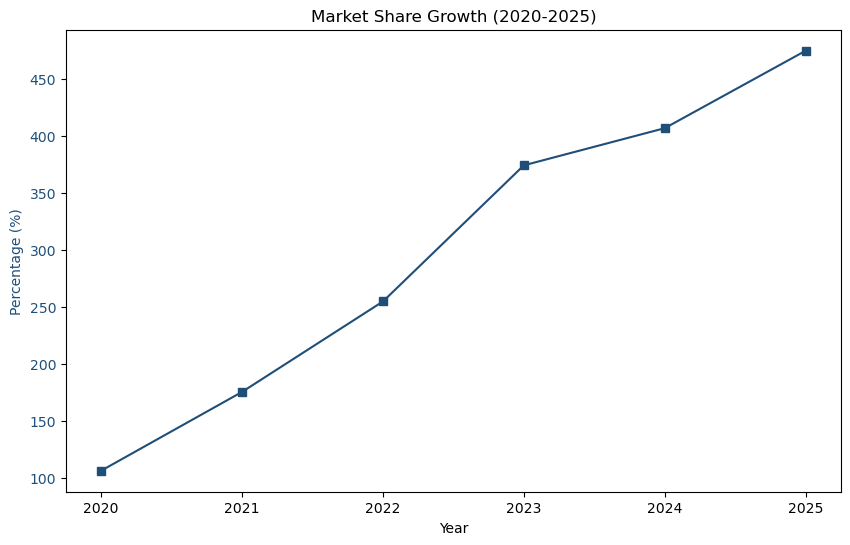

In [48]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Registration Count on the left axis
ax1.set_xlabel('Year')
ax1.set_ylabel('Percentage (%)', color='#1f4e79')
ax1.plot(eu_agg_data['Year'], eu_agg_data['Total_BEVs_percentage'], marker='s', color='#1f4e79', label='Market Share %')
ax1.tick_params(axis='y', labelcolor='#1f4e79')

plt.title('Market Share Growth (2020-2025)')
plt.show()

To check the average of the influencing factors

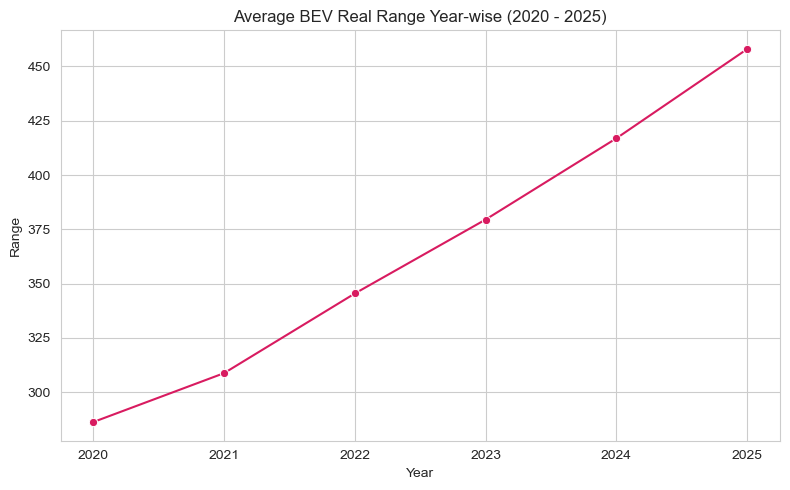

In [49]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Real Range', marker='o', color='#D81B60')

plt.title('Average BEV Real Range Year-wise (2020 - 2025)')
plt.xlabel('Year')
plt.ylabel('Range')

plt.tight_layout()
plt.show()

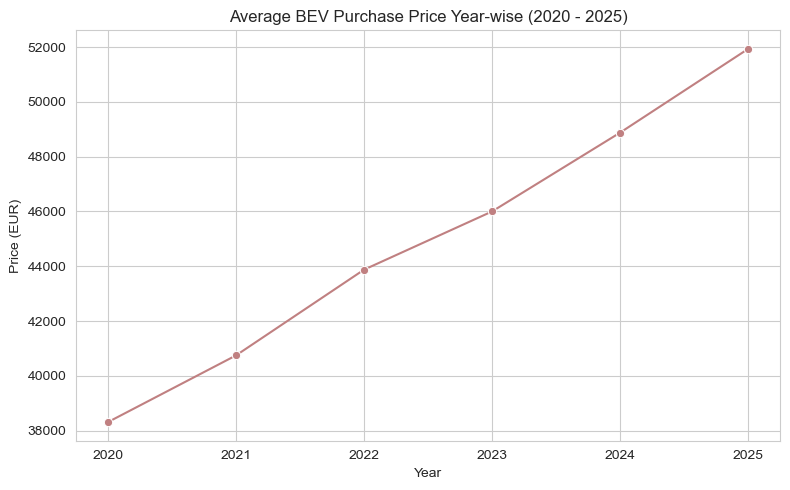

In [50]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Purchase price (EUR)', marker='o', color='#C08081')

plt.title('Average BEV Purchase Price Year-wise (2020 - 2025)')
plt.xlabel('Year')
plt.ylabel('Price (EUR)')

plt.tight_layout()
plt.show()

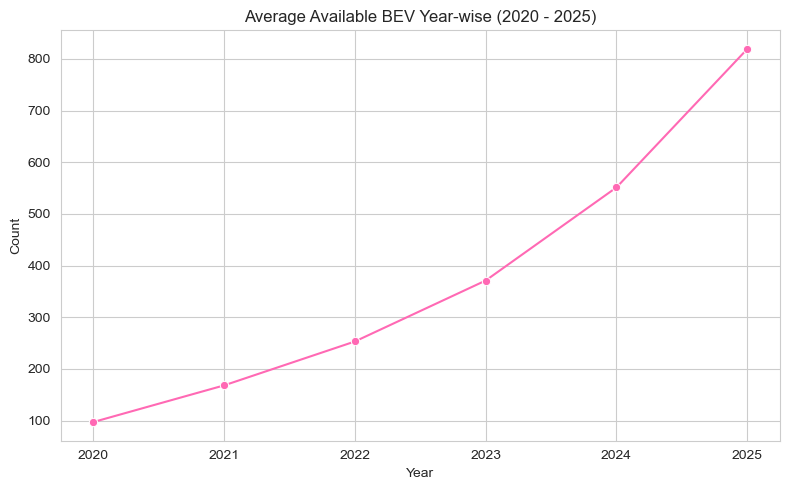

In [51]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Available', marker='o', color='#FF69B4')

plt.title('Average Available BEV Year-wise (2020 - 2025)')
plt.xlabel('Year')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

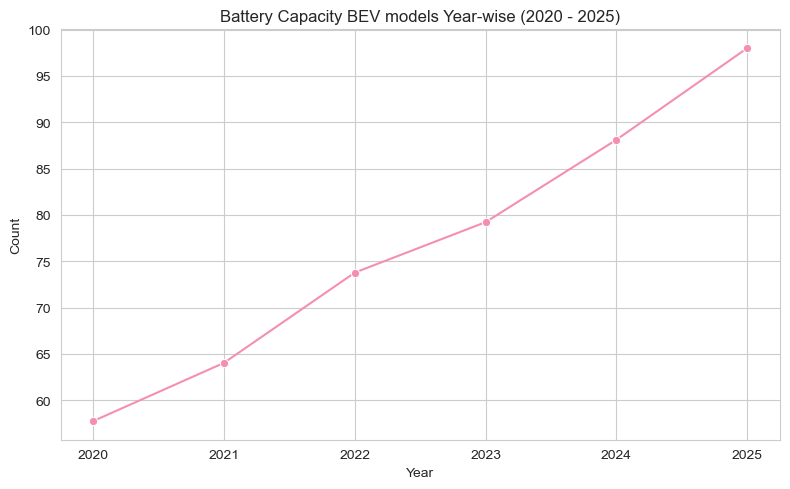

In [52]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.lineplot(data=tech_agg_data, x='Year', y='Battery Capacity', marker='o', color='#F48FB1')

plt.title('Battery Capacity BEV models Year-wise (2020 - 2025)')
plt.xlabel('Year')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Data Transformations

1. Applying Logarithimic Transformation to the dataset only if - skewness is > +1 or < -1 
2. Moderately skewed if - ±0.5 < skewness < ±1
3. Symeytric if - -0.5 < skewness < +0.5

**1. Applying Log transformation for highly skewed columns**

**Literature:** HANDBOOK OF BIOLOGICAL STATISTICS.

In [53]:
# Checking country level skewness
numeric_cols = ['BEV Percentage (Total Number Of Registrations)', 'Recharging Points', 'GDP', 'CPI', 'EG']
for col in numeric_cols:
    print(f"{col} skew before transformation: {dataset[col].skew():.2f}")

BEV Percentage (Total Number Of Registrations) skew before transformation: 1.88
Recharging Points skew before transformation: 2.96
GDP skew before transformation: 5.10
CPI skew before transformation: 1.56
EG skew before transformation: 2.51


In [54]:
# Checking if there is any skewness
average_cols = ['AC Recharging Speed (km/h)', 'DC Recharging Speed (km/h)',
                'Available', 'Battery Capacity', 'Real Range', 'Purchase price (EUR)']

# Drop duplicates across countries — keep unique yearly values
average_data = dataset[['Year'] + average_cols].drop_duplicates(subset=['Year'])

# Print results
average_data[average_cols].skew()

AC Recharging Speed (km/h)   0.9
DC Recharging Speed (km/h)   0.1
Available                    0.9
Battery Capacity             0.2
Real Range                   0.2
Purchase price (EUR)         0.1
dtype: float64

In [55]:
# Country level log transformation
countrylevel_cols = ['BEV Percentage (Total Number Of Registrations)', 'Recharging Points', 'GDP', 'CPI', 'EG']

# Merge in the dataset
for col in countrylevel_cols:
    dataset[f'Log_{col}'] = np.log1p(dataset[col])
    
# Verification
for col in countrylevel_cols:
    print(f"{col} skew before log transform: {dataset[col].skew():.2f}")
    print(f"Log_{col} skew after log1p transform: {dataset[f'Log_{col}'].skew():.2f}\n")

BEV Percentage (Total Number Of Registrations) skew before log transform: 1.88
Log_BEV Percentage (Total Number Of Registrations) skew after log1p transform: 0.25

Recharging Points skew before log transform: 2.96
Log_Recharging Points skew after log1p transform: -0.06

GDP skew before log transform: 5.10
Log_GDP skew after log1p transform: 0.38

CPI skew before log transform: 1.56
Log_CPI skew after log1p transform: -0.32

EG skew before log transform: 2.51
Log_EG skew after log1p transform: -0.51



C:\Users\Disha\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\Disha\anaconda3\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [56]:
# Average level log transformations
average_cols = [
    'AC Recharging Speed (km/h)',
    'Available'
]
average_data = dataset[['Year'] + average_cols].drop_duplicates(subset=['Year']).copy()

# Apply log transform for right-skewed features
average_data['Log_Available'] = np.log1p(average_data['Available'])
average_data['Log_AC Recharging Speed (km/h)'] = np.log1p(average_data['AC Recharging Speed (km/h)'])

# Verification
print("Before log transform (Available):", average_data['Available'].skew())
print("After log transform (Log_Available):", average_data['Log_Available'].skew())
print("Before log transform (AC Recharging Speed (km/h)):", average_data['AC Recharging Speed (km/h)'].skew())
print("After log transform (Log_AC Recharging Speed (km/h)):", average_data['Log_AC Recharging Speed (km/h)'].skew())

Before log transform (Available): 0.9070084114858079
After log transform (Log_Available): -0.18786398621837963
Before log transform (AC Recharging Speed (km/h)): 0.8631947306112712
After log transform (Log_AC Recharging Speed (km/h)): 0.4309012985579439


In [57]:
# Merge back to the main dataset
dataset = dataset.merge(
    average_data[['Year', 'Log_Available', 'Log_AC Recharging Speed (km/h)']],
    on='Year',
    how='left'
)

dataset.head()

,Country,Year,BEV Percentage (Total Number Of Registrations),GDP,CPI,EG,Recharging Points,AC Recharging Speed (km/h),DC Recharging Speed (km/h),Available,Battery Capacity,Real Range,Purchase price (EUR),Log_BEV Percentage (Total Number Of Registrations),Log_Recharging Points,Log_GDP,Log_CPI,Log_EG,Log_Available,Log_AC Recharging Speed (km/h)
0,Austria,2020,6.4,380317.9,1.4,-1.6,26797.0,39.3,403.2,97.0,57.8,286.2,38311.4,2.0,10.2,12.8,0.9,NaN,4.6,3.7
1,Austria,2021,13.9,406231.5,2.8,2.0,39904.0,40.9,493.4,168.0,64.0,308.7,40745.0,2.7,10.6,12.9,1.3,1.1,5.1,3.7
2,Austria,2022,15.7,449382.2,8.5,2.7,61393.0,49.3,594.3,253.0,73.8,345.4,43874.3,2.8,11.0,13.0,2.3,1.3,5.5,3.9
3,Austria,2023,19.9,477837.3,7.8,0.8,76773.0,70.3,649.2,371.0,79.2,379.5,45999.1,3.0,11.2,13.1,2.2,0.6,5.9,4.3
4,Austria,2024,17.6,494087.6,2.9,0.1,102562.0,92.2,744.7,551.3,88.1,416.9,48874.9,2.9,11.5,13.1,1.4,0.1,6.3,4.5


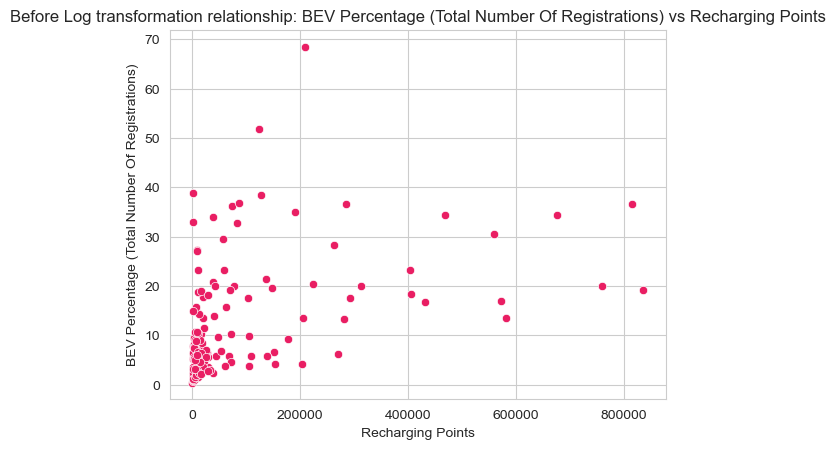

In [58]:
sns.scatterplot(x=dataset['Recharging Points'], y=dataset['BEV Percentage (Total Number Of Registrations)'], color='#E91E63')
plt.title("Before Log transformation relationship: BEV Percentage (Total Number Of Registrations) vs Recharging Points")
plt.show()

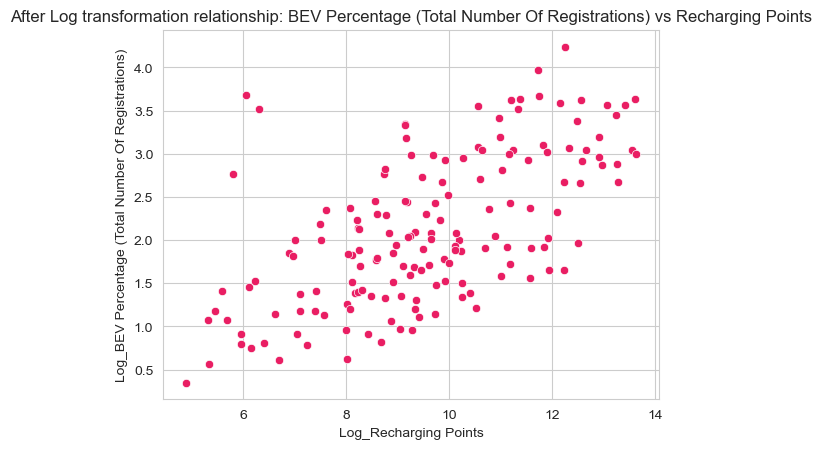

In [59]:
sns.scatterplot(x=dataset['Log_Recharging Points'], y=dataset['Log_BEV Percentage (Total Number Of Registrations)'], color='#E91E63')
plt.title("After Log transformation relationship: BEV Percentage (Total Number Of Registrations) vs Recharging Points")
plt.show()

## Save the dataset

In [60]:
# Save the full clean dataset
dataset.to_csv(r"C:\Users\Disha\TU Braunschweig\Thesis\Data_2025\Cleaned Dataset.csv", index=False)